<a href="https://colab.research.google.com/github/Jee8825/jeeva-codebooster-2026/blob/main/Day_5/Student_Analytics_System_Day5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Standard scientific stack (already available in Colab)
import csv
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [4]:
import os

# --- COLAB UPLOAD (skip if running locally) ---
try:
    from google.colab import files

    csv_filename = 'Student Performance.csv'
    if os.path.exists(csv_filename):
        print(f"'{csv_filename}' already exists. Skipping upload.")
    else:
        print(f"Please upload '{csv_filename}'.")
        uploaded = files.upload() # This opens a file selection dialog
        if csv_filename not in uploaded:
            print(f"Warning: '{csv_filename}' was not uploaded. Please ensure you selected the correct file.")
        else:
            print(f"Successfully uploaded '{csv_filename}'.")

except ImportError:
    print('Not running on Colab — make sure "Student Performance.csv" is in the working directory.')

'Student Performance.csv' already exists. Skipping upload.


In [5]:
CSV_PATH = 'Student Performance.csv'

with open(CSV_PATH, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)
    rows = list(reader)

print(f'Columns ({len(header)}): {header}')
print(f'Total rows: {len(rows)}')
print('First 3 rows:')
for r in rows[:3]:
    print(r)

Columns (13): ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']
Total rows: 30
First 3 rows:
['1001', 'Aarav Sharma', '19', 'Male', 'Computer Science', '2', '85', '78', '72', '91', '92', 'Mumbai', '2023']
['1002', 'Priya Patel', '20', 'Female', 'Computer Science', '2', '76', '82', '88', '79', '87', 'Ahmedabad', '2023']
['1003', 'Rohit Verma', '19', 'Male', 'Electronics', '2', '65', '74', '61', '55', '78', 'Delhi', '2023']


In [6]:
df = pd.read_csv(CSV_PATH)
df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [7]:
print('--- Shape ---')
print(df.shape)
print('\n--- Dtypes ---')
print(df.dtypes)
print('\n--- Missing values ---')
print(df.isnull().sum())
print('\n--- Summary statistics ---')
df.describe()

--- Shape ---
(30, 13)

--- Dtypes ---
student_id                int64
name                     object
age                       int64
gender                   object
department               object
semester                  int64
math_score                int64
science_score             int64
english_score             int64
programming_score         int64
attendance_percentage     int64
city                     object
admission_year            int64
dtype: object

--- Missing values ---
student_id               0
name                     0
age                      0
gender                   0
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64

--- Summary statistics ---


,student_id,age,semester,math_score,science_score,english_score,programming_score,attendance_percentage,admission_year
count,30.000000,30.000000,30.0,30.000000,30.000000,30.000000,30.000000,30.000000,30.0
mean,1015.500000,19.733333,2.0,76.066667,77.833333,74.166667,67.600000,84.500000,2023.0
std,8.803408,0.739680,0.0,11.467896,8.554423,10.003735,21.041175,9.379913,0.0
min,1001.000000,19.000000,2.0,56.000000,61.000000,55.000000,38.000000,65.000000,2023.0
25%,1008.250000,19.000000,2.0,67.250000,71.250000,67.250000,49.250000,77.250000,2023.0
50%,1015.500000,20.000000,2.0,75.500000,78.000000,75.000000,66.000000,86.500000,2023.0
75%,1022.750000,20.000000,2.0,85.750000,83.750000,81.750000,88.750000,91.750000,2023.0
max,1030.000000,21.000000,2.0,95.000000,93.000000,90.000000,97.000000,98.000000,2023.0


In [8]:
print('Departments:', df['department'].unique())
print('Gender split:')
print(df['gender'].value_counts())
print('\nCities (top 5):')
print(df['city'].value_counts().head())

Departments: ['Computer Science' 'Electronics' 'Mechanical' 'Civil']
Gender split:
gender
Male      15
Female    15
Name: count, dtype: int64

Cities (top 5):
city
Kochi                 2
Lucknow               2
Thiruvananthapuram    2
Agra                  2
Kolkata               2
Name: count, dtype: int64


In [9]:
conn = sqlite3.connect(':memory:')
df.to_sql('students', conn, index=False, if_exists='replace')

# Quick sanity check
pd.read_sql('SELECT COUNT(*) AS total_students FROM students;', conn)

,total_students
0,30


In [10]:
q1 = '''
SELECT
    department,
    COUNT(*)                              AS student_count,
    ROUND(AVG(math_score), 2)             AS avg_math,
    ROUND(AVG(science_score), 2)          AS avg_science,
    ROUND(AVG(english_score), 2)          AS avg_english,
    ROUND(AVG(programming_score), 2)      AS avg_programming,
    ROUND(AVG(attendance_percentage), 2)  AS avg_attendance
FROM students
GROUP BY department
ORDER BY avg_programming DESC;
'''
dept_summary = pd.read_sql(q1, conn)
dept_summary

,department,student_count,avg_math,avg_science,avg_english,avg_programming,avg_attendance
0,Computer Science,13,85.62,84.46,80.85,89.23,90.69
1,Electronics,6,71.00,74.17,70.83,61.50,80.33
2,Mechanical,6,71.00,76.50,70.50,49.33,83.50
3,Civil,5,63.40,66.60,65.20,40.60,74.60


In [11]:
q2 = '''
SELECT
    student_id,
    name,
    department,
    ROUND((math_score + science_score + english_score + programming_score) / 4.0, 2) AS overall_avg,
    attendance_percentage
FROM students
ORDER BY overall_avg DESC
LIMIT 10;
'''
top_performers = pd.read_sql(q2, conn)
top_performers

,student_id,name,department,overall_avg,attendance_percentage
0,1010,Ananya Das,Computer Science,92.75,98
1,1022,Tanvi Mehta,Computer Science,91.75,97
2,1030,Akanksha Yadav,Computer Science,91.25,95
3,1005,Arjun Nair,Computer Science,89.00,90
4,1008,Divya Singh,Computer Science,89.00,96
5,1018,Swati Kulkarni,Computer Science,88.50,94
6,1025,Amit Bose,Computer Science,84.00,91
7,1013,Suresh Rao,Computer Science,83.50,88
8,1020,Nisha Kapoor,Computer Science,81.75,89
9,1001,Aarav Sharma,Computer Science,81.50,92


In [12]:
q3 = '''
SELECT
    student_id,
    name,
    department,
    attendance_percentage,
    programming_score,
    CASE
        WHEN attendance_percentage < 75 AND programming_score < 50 THEN 'High Risk'
        WHEN attendance_percentage < 75 OR  programming_score < 50 THEN 'Medium Risk'
        ELSE 'Low Risk'
    END AS risk_level
FROM students
WHERE attendance_percentage < 80 OR programming_score < 60
ORDER BY programming_score ASC, attendance_percentage ASC;
'''
at_risk = pd.read_sql(q3, conn)
at_risk

,student_id,name,department,attendance_percentage,programming_score,risk_level
0,1017,Manoj Pandey,Civil,65,38,High Risk
1,1028,Sunita Pillai,Civil,73,39,High Risk
2,1007,Kiran Kumar,Civil,85,40,Medium Risk
3,1023,Sanjay Dubey,Civil,70,42,High Risk
4,1012,Pooja Gupta,Civil,80,44,Medium Risk
5,1009,Rahul Mishra,Mechanical,68,45,High Risk
6,1004,Sneha Reddy,Mechanical,95,48,Medium Risk
7,1019,Deepak Chauhan,Mechanical,77,49,Medium Risk
8,1029,Nitin Jain,Mechanical,84,50,Low Risk
9,1014,Kavya Nambiar,Mechanical,91,51,Low Risk


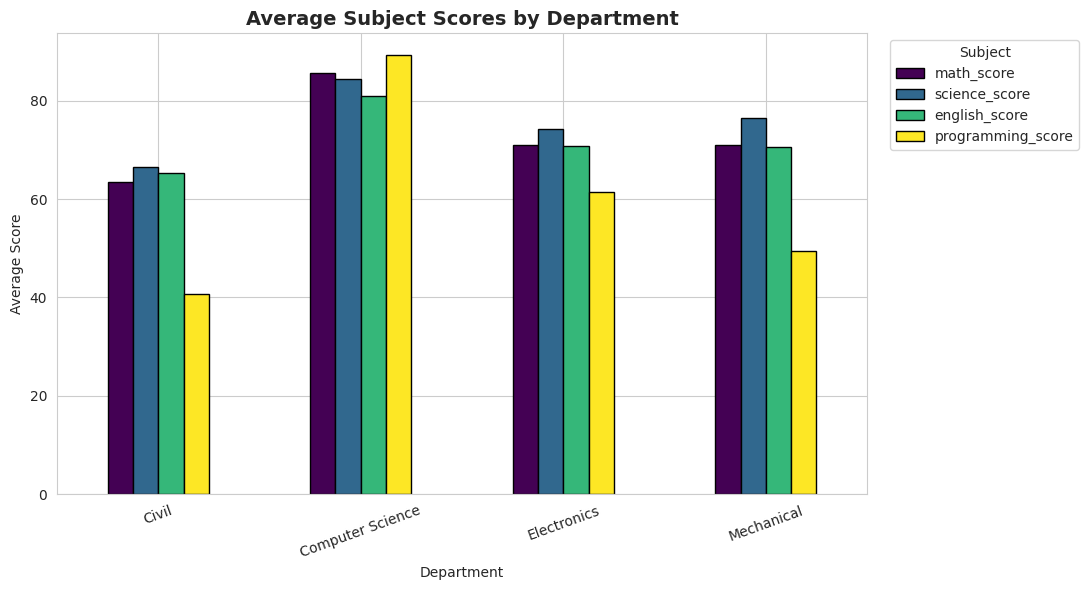

,math_score,science_score,english_score,programming_score
department,,,,
Civil,63.40,66.60,65.20,40.60
Computer Science,85.62,84.46,80.85,89.23
Electronics,71.00,74.17,70.83,61.50
Mechanical,71.00,76.50,70.50,49.33


In [13]:
subject_cols = ['math_score', 'science_score', 'english_score', 'programming_score']
dept_avg = df.groupby('department')[subject_cols].mean().round(2)

ax = dept_avg.plot(kind='bar', figsize=(11, 6), colormap='viridis', edgecolor='black')
ax.set_title('Average Subject Scores by Department', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Score')
ax.set_xlabel('Department')
ax.set_xticklabels(dept_avg.index, rotation=20)
ax.legend(title='Subject', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

dept_avg

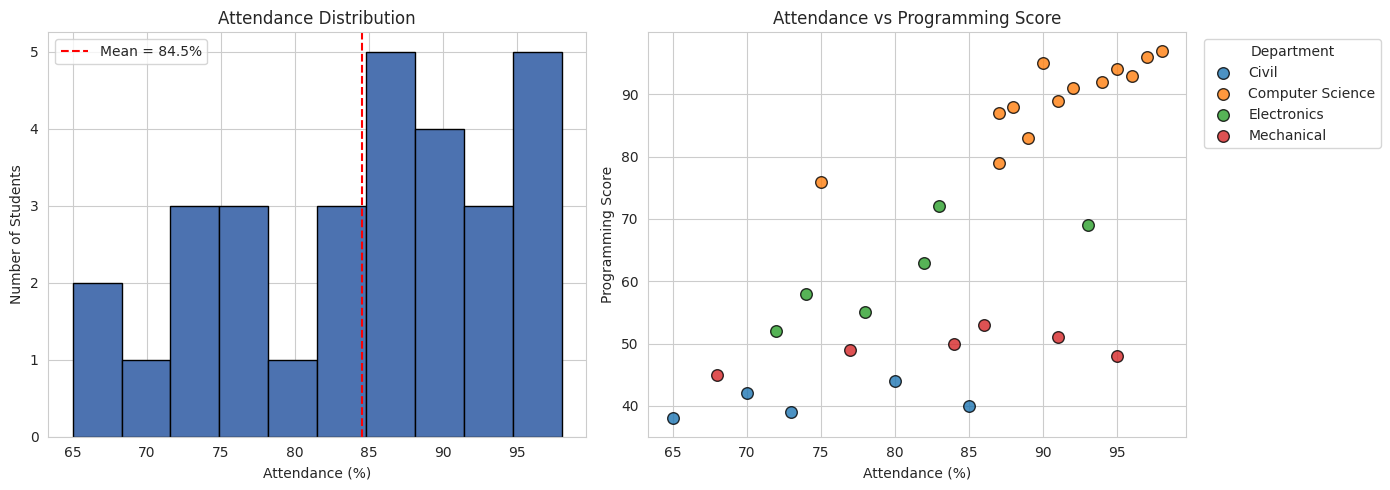

Correlation between attendance and programming score: 0.717


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of attendance
axes[0].hist(df['attendance_percentage'], bins=10, color='#4C72B0', edgecolor='black')
axes[0].axvline(df['attendance_percentage'].mean(), color='red', linestyle='--',
                label=f"Mean = {df['attendance_percentage'].mean():.1f}%")
axes[0].set_title('Attendance Distribution')
axes[0].set_xlabel('Attendance (%)')
axes[0].set_ylabel('Number of Students')
axes[0].legend()

# Attendance vs programming score scatter, colored by department
for dept, sub in df.groupby('department'):
    axes[1].scatter(sub['attendance_percentage'], sub['programming_score'],
                    label=dept, s=70, alpha=0.8, edgecolor='black')
axes[1].set_title('Attendance vs Programming Score')
axes[1].set_xlabel('Attendance (%)')
axes[1].set_ylabel('Programming Score')
axes[1].legend(title='Department', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

corr = df['attendance_percentage'].corr(df['programming_score'])
print(f'Correlation between attendance and programming score: {corr:.3f}')

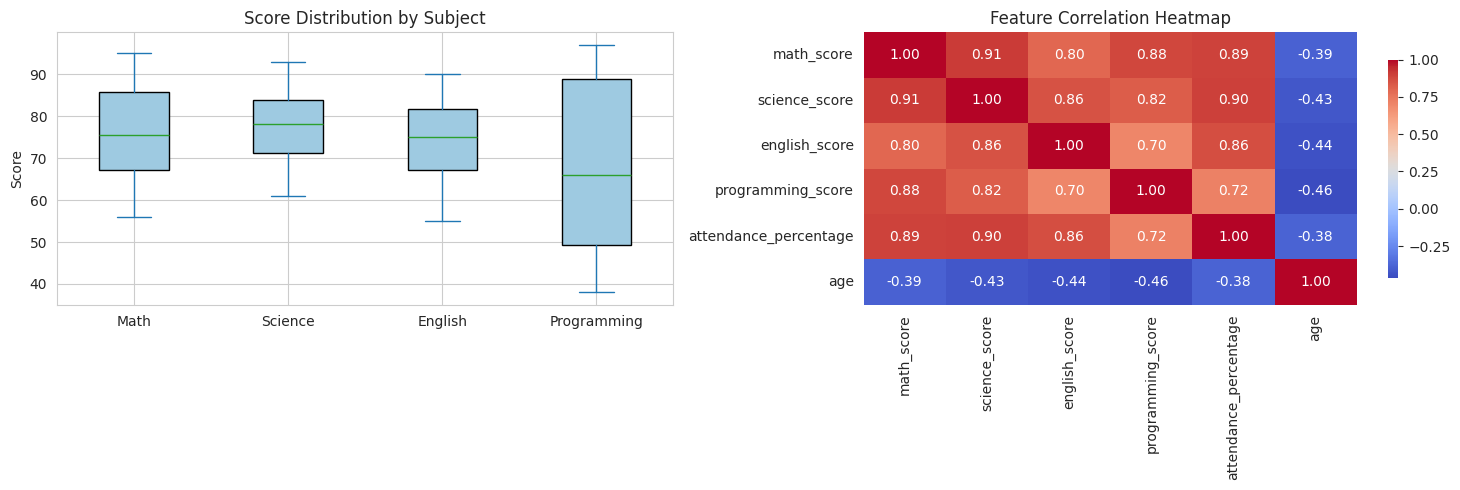

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot of subject scores
df[subject_cols].plot(kind='box', ax=axes[0], patch_artist=True,
                     boxprops=dict(facecolor='#9ECAE1'))
axes[0].set_title('Score Distribution by Subject')
axes[0].set_ylabel('Score')
axes[0].set_xticklabels(['Math', 'Science', 'English', 'Programming'])

# Heatmap of correlations between numeric features
num_cols = subject_cols + ['attendance_percentage', 'age']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f',
            ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

In [16]:
ml_df = df.copy()

# Encode categorical columns
encoders = {}
for col in ['gender', 'department', 'city']:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col])
    encoders[col] = le

feature_cols = [
    'age', 'gender', 'department', 'semester',
    'math_score', 'science_score', 'english_score',
    'attendance_percentage', 'admission_year'
]
X = ml_df[feature_cols]
y = ml_df['programming_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 22 | Test size: 8


In [17]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
preds = model.predict(X_test)

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2   = r2_score(y_test, preds)

print('--- Model Performance ---')
print(f'MAE  : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R^2  : {r2:.3f}')

--- Model Performance ---
MAE  : 9.36
RMSE : 12.43
R^2  : 0.672


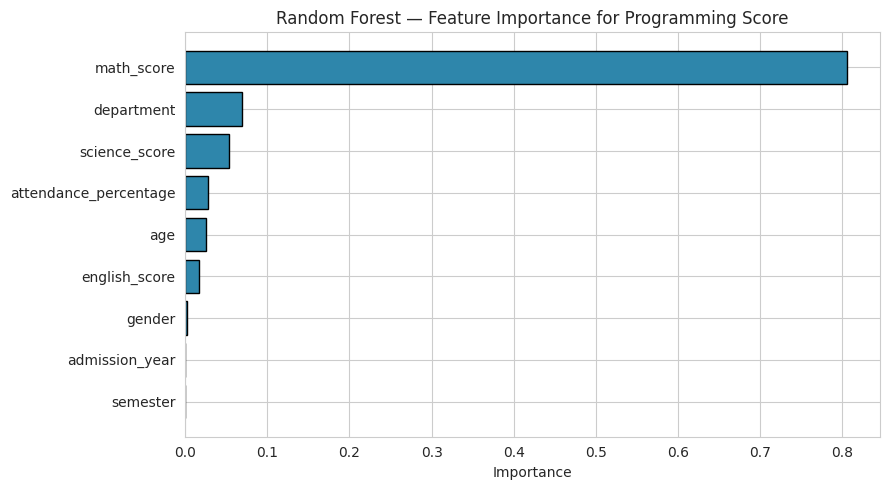

,feature,importance
0,math_score,0.805585
1,department,0.069717
2,science_score,0.053122
3,attendance_percentage,0.027866
4,age,0.024805
5,english_score,0.016249
6,gender,0.002656
7,semester,0.000000
8,admission_year,0.000000


In [18]:
# Feature importance
importance = (
    pd.DataFrame({'feature': feature_cols, 'importance': model.feature_importances_})
    .sort_values('importance', ascending=True)
)

plt.figure(figsize=(9, 5))
plt.barh(importance['feature'], importance['importance'], color='#2E86AB', edgecolor='black')
plt.title('Random Forest — Feature Importance for Programming Score')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importance.sort_values('importance', ascending=False).reset_index(drop=True)

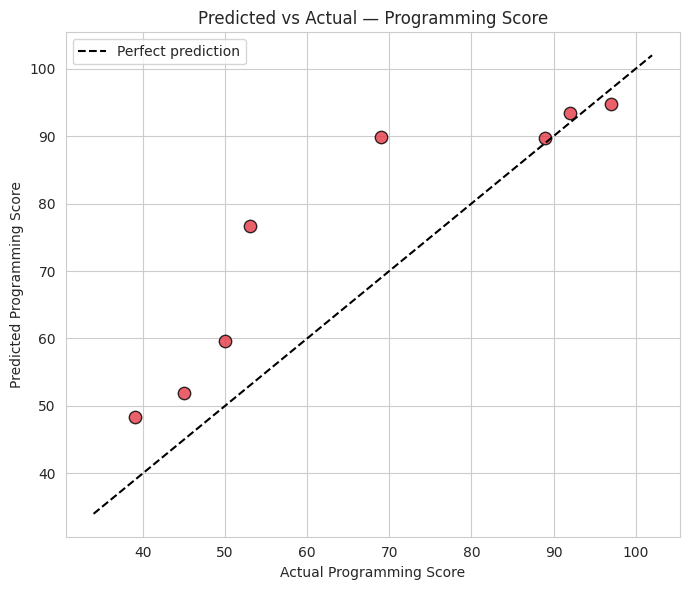

In [19]:
# Predicted vs actual
plt.figure(figsize=(7, 6))
plt.scatter(y_test, preds, s=80, alpha=0.8, edgecolor='black', color='#E63946')
lims = [min(y_test.min(), preds.min()) - 5, max(y_test.max(), preds.max()) + 5]
plt.plot(lims, lims, 'k--', label='Perfect prediction')
plt.xlabel('Actual Programming Score')
plt.ylabel('Predicted Programming Score')
plt.title('Predicted vs Actual — Programming Score')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
total_students   = len(df)
avg_attendance   = df['attendance_percentage'].mean()
best_dept_prog   = dept_summary.iloc[0]['department']
best_dept_score  = dept_summary.iloc[0]['avg_programming']
worst_dept_prog  = dept_summary.iloc[-1]['department']
worst_dept_score = dept_summary.iloc[-1]['avg_programming']
top_student      = top_performers.iloc[0]
high_risk_count  = (
    (df['attendance_percentage'] < 75) & (df['programming_score'] < 50)
).sum()
att_corr         = df['attendance_percentage'].corr(df['programming_score'])
top_feature      = importance.sort_values('importance', ascending=False).iloc[0]['feature']

report = f'''
============================================================
          STUDENT ANALYTICS — BUSINESS SUMMARY REPORT
============================================================

OVERVIEW
  - Total students analysed     : {total_students}
  - Average attendance          : {avg_attendance:.1f}%
  - Departments covered         : {df['department'].nunique()}
  - Cities represented          : {df['city'].nunique()}

DEPARTMENT PERFORMANCE
  - Top department (programming)    : {best_dept_prog} ({best_dept_score:.1f})
  - Lowest department (programming) : {worst_dept_prog} ({worst_dept_score:.1f})
  - Gap between top & bottom        : {best_dept_score - worst_dept_score:.1f} points

TALENT SPOTLIGHT
  - Top overall performer : {top_student["name"]} ({top_student["department"]})
    overall average = {top_student["overall_avg"]:.1f}
    attendance      = {top_student["attendance_percentage"]}%

ATTENDANCE INSIGHT
  - Correlation(attendance, programming) = {att_corr:.2f}
    -> Attendance is {"strongly" if abs(att_corr) > 0.6 else "moderately" if abs(att_corr) > 0.3 else "weakly"} linked to programming outcomes.

RISK SIGNAL
  - Students flagged HIGH RISK (attendance < 75% AND programming < 50): {high_risk_count}
  - Recommend targeted mentoring + remedial programming labs.

PREDICTIVE MODEL (Random Forest)
  - R^2 on hold-out set        : {r2:.2f}
  - MAE                        : {mae:.2f}
  - Most predictive feature    : {top_feature}

RECOMMENDATIONS
  1. Replicate {best_dept_prog}'s teaching pattern in {worst_dept_prog}.
  2. Mandate >=80% attendance — model shows it materially drives programming scores.
  3. Run an early-warning system on the {high_risk_count} high-risk students this semester.
  4. Use the trained Random Forest to flag predicted under-performers before mid-term.

============================================================
'''
print(report)

# Persist the report next to the notebook
with open('business_summary_report.txt', 'w') as f:
    f.write(report)
print('Saved -> business_summary_report.txt')


          STUDENT ANALYTICS — BUSINESS SUMMARY REPORT

OVERVIEW
  - Total students analysed     : 30
  - Average attendance          : 84.5%
  - Departments covered         : 4
  - Cities represented          : 25

DEPARTMENT PERFORMANCE
  - Top department (programming)    : Computer Science (89.2)
  - Lowest department (programming) : Civil (40.6)
  - Gap between top & bottom        : 48.6 points

TALENT SPOTLIGHT
  - Top overall performer : Ananya Das (Computer Science)
    overall average = 92.8
    attendance      = 98%

ATTENDANCE INSIGHT
  - Correlation(attendance, programming) = 0.72
    -> Attendance is strongly linked to programming outcomes.

RISK SIGNAL
  - Students flagged HIGH RISK (attendance < 75% AND programming < 50): 4
  - Recommend targeted mentoring + remedial programming labs.

PREDICTIVE MODEL (Random Forest)
  - R^2 on hold-out set        : 0.67
  - MAE                        : 9.36
  - Most predictive feature    : math_score

RECOMMENDATIONS
  1. Replicate Comp

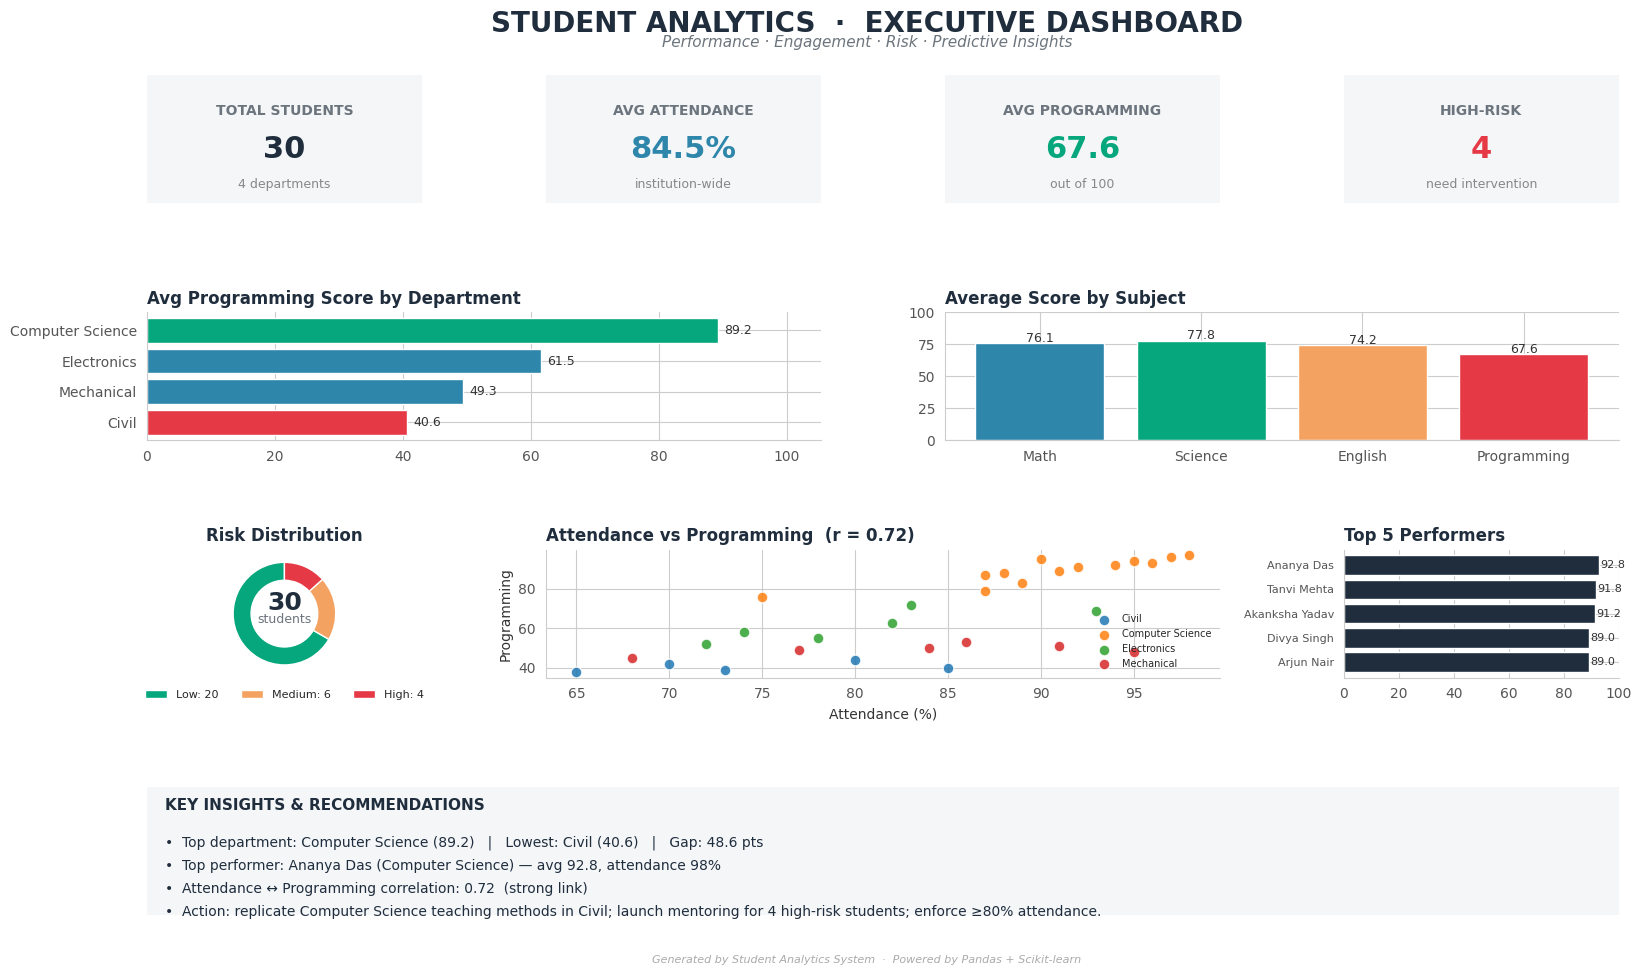

Dashboard saved → student_dashboard.png


In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# ---------- prep metrics ----------
total_students   = len(df)
avg_attendance   = df['attendance_percentage'].mean()
avg_programming  = df['programming_score'].mean()
dept_count       = df['department'].nunique()

dept_summary_sorted = (
    df.groupby('department')['programming_score']
      .mean().round(2).sort_values(ascending=True)
)
best_dept_prog   = dept_summary_sorted.index[-1]
best_dept_score  = dept_summary_sorted.iloc[-1]
worst_dept_prog  = dept_summary_sorted.index[0]
worst_dept_score = dept_summary_sorted.iloc[0]

high_risk_count = ((df['attendance_percentage'] < 75) & (df['programming_score'] < 50)).sum()
med_risk_count  = (((df['attendance_percentage'] < 75) | (df['programming_score'] < 50))
                   & ~((df['attendance_percentage'] < 75) & (df['programming_score'] < 50))).sum()
low_risk_count  = total_students - high_risk_count - med_risk_count

att_corr = df['attendance_percentage'].corr(df['programming_score'])

top_student = (
    df.assign(overall=(df['math_score']+df['science_score']+df['english_score']+df['programming_score'])/4)
      .sort_values('overall', ascending=False).iloc[0]
)

subject_cols = ['math_score','science_score','english_score','programming_score']
subject_means = df[subject_cols].mean()

# ---------- style ----------
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.edgecolor': '#cccccc',
    'axes.labelcolor': '#333333',
    'xtick.color': '#555555',
    'ytick.color': '#555555',
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'axes.titlecolor': '#1f2d3d',
})

NAVY   = '#1f2d3d'
BLUE   = '#2E86AB'
TEAL   = '#06A77D'
AMBER  = '#F4A261'
RED    = '#E63946'
LIGHT  = '#F4F6F8'

fig = plt.figure(figsize=(16, 10), facecolor='white')
gs  = gridspec.GridSpec(4, 4, figure=fig, hspace=0.85, wspace=0.45,
                        left=0.05, right=0.97, top=0.90, bottom=0.06)

# ---------- header ----------
fig.suptitle('STUDENT ANALYTICS  ·  EXECUTIVE DASHBOARD',
             fontsize=20, fontweight='bold', color=NAVY, y=0.965)
fig.text(0.5, 0.928, 'Performance · Engagement · Risk · Predictive Insights',
         ha='center', fontsize=11, color='#6c757d', style='italic')

# ---------- KPI cards ----------
def kpi(ax, title, value, sub, color):
    ax.set_facecolor(LIGHT)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.72, title, ha='center', va='center',
            fontsize=10, color='#6c757d', weight='bold')
    ax.text(0.5, 0.42, value, ha='center', va='center',
            fontsize=22, color=color, weight='bold')
    ax.text(0.5, 0.15, sub, ha='center', va='center',
            fontsize=9, color='#888888')

kpi(fig.add_subplot(gs[0,0]), 'TOTAL STUDENTS',  f'{total_students}',
    f'{dept_count} departments', NAVY)
kpi(fig.add_subplot(gs[0,1]), 'AVG ATTENDANCE',  f'{avg_attendance:.1f}%',
    'institution-wide', BLUE)
kpi(fig.add_subplot(gs[0,2]), 'AVG PROGRAMMING', f'{avg_programming:.1f}',
    'out of 100', TEAL)
kpi(fig.add_subplot(gs[0,3]), 'HIGH-RISK',       f'{high_risk_count}',
    'need intervention', RED)

# ---------- department bar ----------
ax1 = fig.add_subplot(gs[1, 0:2])
colors = [TEAL if d == best_dept_prog else RED if d == worst_dept_prog else BLUE
          for d in dept_summary_sorted.index]
bars = ax1.barh(dept_summary_sorted.index, dept_summary_sorted.values,
                color=colors, edgecolor='white')
for b, v in zip(bars, dept_summary_sorted.values):
    ax1.text(v + 1, b.get_y() + b.get_height()/2, f'{v:.1f}',
             va='center', fontsize=9, color='#333')
ax1.set_title('Avg Programming Score by Department', loc='left')
ax1.set_xlim(0, max(dept_summary_sorted.values) * 1.18)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# ---------- subject means radar-ish bar ----------
ax2 = fig.add_subplot(gs[1, 2:4])
sb = ax2.bar(['Math','Science','English','Programming'], subject_means.values,
             color=[BLUE, TEAL, AMBER, RED], edgecolor='white')
for b, v in zip(sb, subject_means.values):
    ax2.text(b.get_x() + b.get_width()/2, v + 1, f'{v:.1f}',
             ha='center', fontsize=9, color='#333')
ax2.set_title('Average Score by Subject', loc='left')
ax2.set_ylim(0, 100)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# ---------- risk donut ----------
ax3 = fig.add_subplot(gs[2, 0])
sizes  = [low_risk_count, med_risk_count, high_risk_count]
labels = ['Low', 'Medium', 'High']
colors_r = [TEAL, AMBER, RED]
wedges, _ = ax3.pie(sizes, colors=colors_r, startangle=90,
                    wedgeprops=dict(width=0.35, edgecolor='white'))
ax3.text(0, 0.08, f'{total_students}', ha='center', fontsize=18,
         weight='bold', color=NAVY)
ax3.text(0, -0.18, 'students', ha='center', fontsize=9, color='#6c757d')
ax3.set_title('Risk Distribution', loc='center')
ax3.legend(wedges, [f'{l}: {s}' for l, s in zip(labels, sizes)],
           loc='lower center', bbox_to_anchor=(0.5, -0.25),
           frameon=False, fontsize=8, ncol=3)

# ---------- attendance vs programming scatter ----------
ax4 = fig.add_subplot(gs[2, 1:3])
for dept, sub in df.groupby('department'):
    ax4.scatter(sub['attendance_percentage'], sub['programming_score'],
                label=dept, s=60, alpha=0.85, edgecolor='white')
ax4.set_title(f'Attendance vs Programming  (r = {att_corr:.2f})', loc='left')
ax4.set_xlabel('Attendance (%)'); ax4.set_ylabel('Programming')
ax4.legend(fontsize=7, loc='lower right', frameon=False)
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)

# ---------- top performers ----------
ax5 = fig.add_subplot(gs[2, 3])
top5 = (df.assign(overall=(df['math_score']+df['science_score']
        +df['english_score']+df['programming_score'])/4)
          .sort_values('overall', ascending=True).tail(5))
ax5.barh(top5['name'], top5['overall'], color=NAVY, edgecolor='white')
for i, v in enumerate(top5['overall'].values):
    ax5.text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=8, color='#333')
ax5.set_title('Top 5 Performers', loc='left')
ax5.set_xlim(0, 100)
ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)
ax5.tick_params(axis='y', labelsize=8)

# ---------- insights panel ----------
ax6 = fig.add_subplot(gs[3, :])
ax6.set_facecolor(LIGHT)
for s in ax6.spines.values(): s.set_visible(False)
ax6.set_xticks([]); ax6.set_yticks([])
ax6.text(0.012, 0.82, 'KEY INSIGHTS & RECOMMENDATIONS',
         fontsize=11, weight='bold', color=NAVY)

insights = [
    f"Top department: {best_dept_prog} ({best_dept_score:.1f})   |   "
    f"Lowest: {worst_dept_prog} ({worst_dept_score:.1f})   |   "
    f"Gap: {best_dept_score - worst_dept_score:.1f} pts",
    f"Top performer: {top_student['name']} ({top_student['department']}) — "
    f"avg {top_student['overall']:.1f}, attendance {top_student['attendance_percentage']}%",
    f"Attendance ↔ Programming correlation: {att_corr:.2f}  "
    f"({'strong' if abs(att_corr)>0.6 else 'moderate' if abs(att_corr)>0.3 else 'weak'} link)",
    f"Action: replicate {best_dept_prog} teaching methods in {worst_dept_prog}; "
    f"launch mentoring for {high_risk_count} high-risk students; enforce ≥80% attendance.",
]
for i, line in enumerate(insights):
    ax6.text(0.012, 0.62 - i*0.18, f'•  {line}',
             fontsize=10, color='#1f2d3d', va='top')

# ---------- footer ----------
fig.text(0.5, 0.012, 'Generated by Student Analytics System  ·  Powered by Pandas + Scikit-learn',
         ha='center', fontsize=8, color='#aaaaaa', style='italic')

plt.savefig('student_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Dashboard saved → student_dashboard.png')